In [4]:
! pip install torch torchvision matplotlib

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.3 MB 11.8 MB/s eta 0:00:01
   ----------------- ---------------------- 4.2/9.3 MB 10.5 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.3 MB 10.7 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.3 MB 10.5 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 9.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ----------------------------------- ---- 2.1/2.3 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 10.3 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Acer\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [3]:
from torchvision import transforms

In [2]:
device ="cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


In [4]:
transform = transforms.ToTensor()

In [5]:
train_data = MNIST(root='./data', train=True, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [01:18<00:00, 127kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 93.4kB/s]
100%|██████████| 1.65M/1.65M [00:14<00:00, 114kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.80MB/s]


In [6]:
test_data = MNIST(root='./data', train=False, download=True, transform=transform)

In [7]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [8]:
class DigitClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    
    def forward(self, x):
        return self.net(x)
    
model = DigitClassifier().to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
    
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [1/5], Loss: 0.0976
Epoch [2/5], Loss: 0.1117
Epoch [3/5], Loss: 0.0152
Epoch [4/5], Loss: 0.2276
Epoch [5/5], Loss: 0.0006


In [9]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        predicted = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total:.2f}%")

Accuracy: 97.80%


In [10]:
torch.save(model.state_dict(), 'digit_classifier.pth')
print("Model saved as digit_classifier.pth")

Model saved as digit_classifier.pth


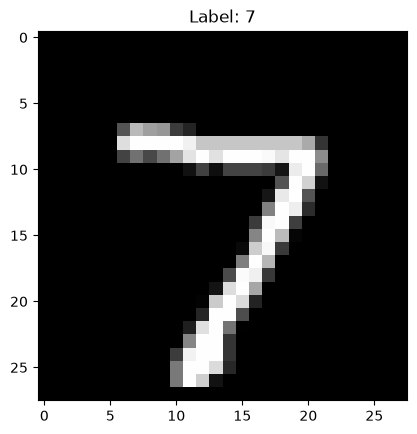

User picked image index 0
Predicted label: 7
Actual label: 7


In [11]:
index = 0
image, label = test_data[index]
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f'Label: {label}')
plt.show()

image_flat = image.view(1, -1).to(device)

with torch.no_grad():
    output = model(image_flat)
    predicted_label = output.argmax(dim=1).item()

print("User picked image index",index)
print("Predicted label:", predicted_label)
print("Actual label:", label)
